# Statistical Learning Theory

Statistical Learning Theory (SLT) provides the mathematical foundation for understanding how machine learning algorithms learn from data and why they can generalize to unseen examples.

The main question is:

> How can we learn a model from a finite amount of training data and still expect it to perform well on unseen data?

Statistical Learning Theory studies:

- Learning from finite data
- Generalization
- Empirical risk
- True risk
- Hypothesis spaces
- Model complexity
- PAC learning
- VC dimension
- Generalization bounds
- Overfitting
- Regularization
- Structural Risk Minimization

The goal is not only to build a model that performs well on training data, but to understand why a learned model can perform well on new data.

## 1. What is Statistical Learning Theory?

Statistical Learning Theory studies the mathematical principles behind learning from data.

Suppose we have training examples:

$$
D = \{(x_1,y_1),(x_2,y_2),\ldots,(x_n,y_n)\}
$$

where:

- $x_i$ is an input
- $y_i$ is the corresponding target
- $n$ is the number of training examples

A learning algorithm uses this dataset to select a model from a hypothesis space.

The central objective is:

$$
\text{Learn a model that performs well on unseen data.}
$$

This is called **generalization**.

## Why Do We Need Statistical Learning Theory?

A machine learning model can achieve very low training error without actually learning a useful pattern.

For example:

- Training accuracy = 100%
- Test accuracy = 65%

The model has memorized the training data instead of learning a general pattern.

Statistical Learning Theory helps us understand:

1. Why overfitting happens
2. How model complexity affects generalization
3. How much data is needed
4. Why simpler models can sometimes generalize better
5. How regularization improves generalization
6. How training performance relates to unseen-data performance

Therefore, SLT provides a theoretical explanation for many practical machine learning concepts.

# 2. The Statistical Learning Problem

Assume that data is generated from an unknown probability distribution:

$$
P(X,Y)
$$

We observe a finite training dataset:

$$
D = \{(x_1,y_1),\ldots,(x_n,y_n)\}
$$

The learning algorithm receives $D$ and selects a function:

$$
f : X \rightarrow Y
$$

The goal is to find a function that makes accurate predictions on future samples drawn from the same underlying distribution.

The difficulty is that we do not know the true distribution $P(X,Y)$.

We only observe a finite sample from it.

# 3. Hypothesis Space

A **hypothesis** is a possible model that can be used to make predictions.

The set of all candidate models is called the **hypothesis space**.

It is usually represented by:

$$
\mathcal{H}
$$

For example, suppose we are fitting a polynomial regression model.

A simple hypothesis space might contain:

$$
\mathcal{H}_1 =
\{\text{all linear functions}\}
$$

Another hypothesis space might contain:

$$
\mathcal{H}_2 =
\{\text{all quadratic functions}\}
$$

A larger hypothesis space allows more complex models.

Therefore:

$$
\text{Larger hypothesis space}
\Rightarrow
\text{Higher model flexibility}
$$

But higher flexibility can also increase the risk of overfitting.

## Example of Hypothesis Spaces

Consider polynomial regression.

### Degree 1

$$
f(x) = w_0 + w_1x
$$

This produces a linear model.

### Degree 2

$$
f(x) = w_0 + w_1x + w_2x^2
$$

This allows a quadratic relationship.

### Degree 10

$$
f(x) =
w_0+w_1x+w_2x^2+\cdots+w_{10}x^{10}
$$

This model can represent much more complicated patterns.

Therefore:

$$
\text{Complexity of } \mathcal{H}
\uparrow
\Rightarrow
\text{Flexibility}
\uparrow
$$

But excessive flexibility can lead to overfitting.

# 4. Risk

To evaluate a prediction, we define a **loss function**.

A loss function measures how bad a prediction is.

For example, in regression we can use squared loss:

$$
L(y,\hat{y}) = (y-\hat{y})^2
$$

For classification, we can use 0-1 loss:

$$
L(y,\hat{y}) =
\begin{cases}
0 & \text{if } y=\hat{y} \\
1 & \text{if } y\neq\hat{y}
\end{cases}
$$

Risk is the expected value of the loss.

# 5. True Risk

The **true risk** is the expected loss of a model over the unknown data distribution.

For a hypothesis $h$, true risk is:

$$
R(h)
=
\mathbb{E}_{(X,Y)\sim P}
[L(Y,h(X))]
$$

This represents the model's expected performance on unseen data.

The ideal learning objective would therefore be:

$$
h^*
=
\arg\min_{h\in\mathcal{H}} R(h)
$$

However, there is a major problem:

We usually do not know the true distribution $P(X,Y)$.

Therefore, we cannot directly calculate $R(h)$.

# 6. Empirical Risk

Since the true distribution is unknown, we estimate risk using the training dataset.

This is called **empirical risk**.

The empirical risk of hypothesis $h$ is:

$$
\hat{R}(h)
=
\frac{1}{n}
\sum_{i=1}^{n}
L(y_i,h(x_i))
$$

It is simply the average loss on the training data.

The learning algorithm can minimize empirical risk:

$$
\hat{h}
=
\arg\min_{h\in\mathcal{H}}
\hat{R}(h)
$$

This principle is called:

**Empirical Risk Minimization (ERM).**

# 7. True Risk vs Empirical Risk

There are two important quantities:

### Empirical Risk

Measured using training data:

$$
\hat{R}(h)
$$

### True Risk

Expected loss over the underlying distribution:

$$
R(h)
$$

The goal of machine learning is not simply:

$$
\min \hat{R}(h)
$$

Instead, we ultimately care about:

$$
\min R(h)
$$

The central theoretical question is therefore:

> How close is empirical risk to true risk?

This question leads directly to **generalization theory**.

# 8. Generalization

**Generalization** is the ability of a machine learning model to perform well on unseen data.

A model generalizes well when:

$$
R(h) \approx \hat{R}(h)
$$

A large difference between true risk and empirical risk indicates poor generalization.

The difference can be represented as:

$$
R(h)-\hat{R}(h)
$$

This is related to the **generalization gap**.

A small generalization gap generally indicates that the model's training performance is representative of its expected performance on unseen data.

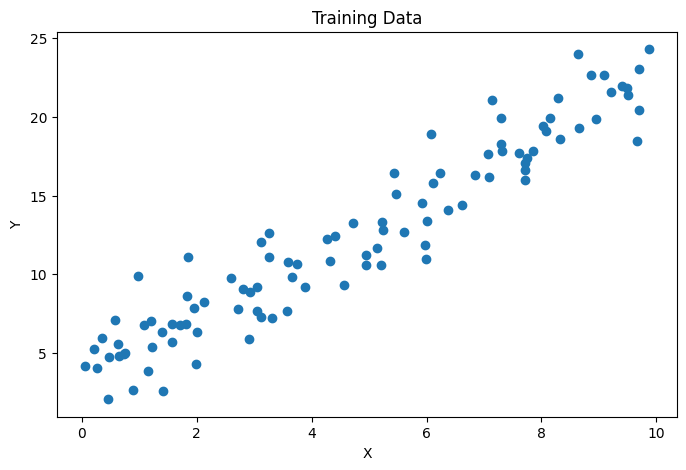

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100

x = np.random.uniform(0, 10, n)

y = 2 * x + 3 + np.random.normal(0, 2, n)

plt.figure(figsize=(8, 5))

plt.scatter(x, y)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Training Data")

plt.show()

# 9. Training Error and Test Error

Training error is calculated using the training dataset:

$$
E_{train}
=
\frac{1}{n}
\sum_{i=1}^{n}
L(y_i,\hat{y}_i)
$$

Test error is calculated using unseen test data:

$$
E_{test}
=
\frac{1}{m}
\sum_{i=1}^{m}
L(y_i,\hat{y}_i)
$$

A model that generalizes well should have similar training and test performance.

For example:

$$
E_{train}=0.05
$$

and

$$
E_{test}=0.07
$$

indicates a relatively small gap.

But:

$$
E_{train}=0.01
$$

and

$$
E_{test}=0.45
$$

suggests severe overfitting.

# 10. Empirical Risk Minimization

Empirical Risk Minimization (ERM) chooses the hypothesis with the lowest training loss.

The objective is:

$$
\hat{h}
=
\arg\min_{h\in\mathcal{H}}
\hat{R}(h)
$$

This is a fundamental idea behind many machine learning algorithms.

Examples include:

- Linear Regression
- Logistic Regression
- Support Vector Machines
- Neural Networks
- Decision Trees

However, minimizing training error alone is not always sufficient.

If the hypothesis space is extremely flexible, the model may memorize the training data.

Therefore:

$$
\text{Low empirical risk}
\not\Rightarrow
\text{Low true risk}
$$

This is one of the most important ideas in Statistical Learning Theory.

# 11. PAC Learning

PAC stands for:

**Probably Approximately Correct**

The PAC framework provides a mathematical way to describe whether a learning algorithm can learn a good hypothesis from a finite amount of data.

The basic idea is:

> With high probability, the learned model should have sufficiently small error.

Two important parameters are:

### Accuracy

$$
\epsilon
$$

This represents how much error we are willing to tolerate.

### Confidence

$$
1-\delta
$$

This represents how confident we want to be that the learned model satisfies the desired error requirement.

A PAC-style guarantee can be expressed as:

$$
P(R(h)\leq\epsilon)
\geq
1-\delta
$$

In words:

> With probability at least $1-\delta$, the learned hypothesis has true error at most $\epsilon$.

## Understanding $\epsilon$ and $\delta$

Suppose:

$$
\epsilon = 0.05
$$

and

$$
\delta = 0.01
$$

Then:

$$
1-\delta = 0.99
$$

The PAC statement means that we want:

$$
R(h)\leq0.05
$$

with at least:

$$
99\%
$$

confidence.

Therefore:

- Smaller $\epsilon$ → require better accuracy
- Smaller $\delta$ → require higher confidence
- Both usually require more training data

# 13. Sample Complexity

**Sample complexity** asks:

> How many training examples are required to learn a model with a desired level of accuracy and confidence?

The required number of samples depends on factors such as:

- Model complexity
- Desired accuracy
- Desired confidence
- Noise in the data
- Structure of the hypothesis space

Generally:

$$
\text{Model complexity}
\uparrow
\Rightarrow
\text{Required data}
\uparrow
$$

and:

$$
\epsilon \downarrow
\Rightarrow
n \uparrow
$$

and:

$$
\delta \downarrow
\Rightarrow
n \uparrow
$$

This explains why highly flexible models often need large datasets.

# 14. VC Dimension

The **VC Dimension** is a concept used to measure the expressive power or capacity of a hypothesis class.

VC stands for:

**Vapnik–Chervonenkis**

Informally, the VC dimension measures how many points a hypothesis class can classify in all possible ways.

If a hypothesis class can correctly realize every possible labeling of $n$ points, then those points are said to be **shattered**.

If the largest number of points that can be shattered is $d$, then:

$$
VC(\mathcal{H}) = d
$$

A higher VC dimension generally indicates a more expressive hypothesis class.

## Simple VC Dimension Example

Consider a linear classifier in one dimension.

A threshold classifier can look like:

$$
h(x)=
\begin{cases}
1 & x > t \\
0 & x \leq t
\end{cases}
$$

This classifier has limited flexibility.

Now consider a more complex classifier capable of creating many different decision boundaries.

It can represent more labeling patterns.

Therefore, its hypothesis space has greater capacity.

The important idea is:

$$
\text{VC Dimension}
\approx
\text{Capacity of a hypothesis class}
$$

Higher capacity means more possible functions can be represented.

# 16. VC Dimension and Generalization

VC dimension connects model complexity with generalization.

A simplified theoretical relationship is:

$$
\text{Generalization error}
\lesssim
\text{Training error}
+
\text{Complexity term}
$$

The complexity term depends on factors such as:

- VC dimension
- Number of training examples
- Desired confidence

Conceptually:

$$
\text{Generalization}
\approx
\text{Fit to data}
+
\text{Control of complexity}
$$

Therefore, a model that is extremely flexible may have very low training error but still generalize poorly.

# 17. Model Complexity

Model complexity describes how flexible a model is.

Examples:

### Low complexity

- Linear regression
- Simple decision tree
- Small hypothesis space

### High complexity

- High-degree polynomial
- Deep decision tree
- Large neural network
- Very flexible hypothesis space

Increasing complexity can reduce training error:

$$
\text{Complexity}\uparrow
\Rightarrow
\hat{R}(h)\downarrow
$$

But after some point, true risk can increase:

$$
\text{Complexity}\uparrow
\Rightarrow
R(h)\uparrow
$$

This is one of the theoretical explanations of overfitting.

## 18. Complexity vs Generalization

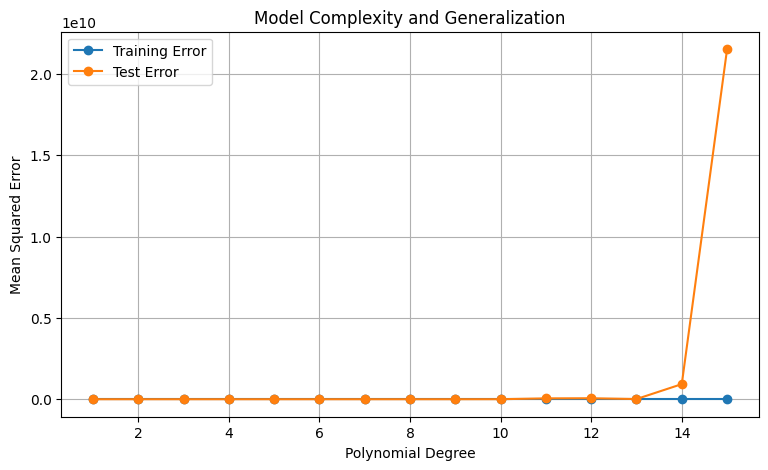

In [2]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

np.random.seed(42)

x = np.linspace(0, 10, 100)

y = np.sin(x) + np.random.normal(0, 0.2, 100)

x_train = x[:70]
y_train = y[:70]

x_test = x[70:]
y_test = y[70:]

degrees = range(1, 16)

train_errors = []
test_errors = []

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(x_train.reshape(-1, 1), y_train)

    train_pred = model.predict(x_train.reshape(-1, 1))
    test_pred = model.predict(x_test.reshape(-1, 1))

    train_errors.append(
        mean_squared_error(y_train, train_pred)
    )

    test_errors.append(
        mean_squared_error(y_test, test_pred)
    )

plt.figure(figsize=(9, 5))

plt.plot(degrees, train_errors, marker="o", label="Training Error")
plt.plot(degrees, test_errors, marker="o", label="Test Error")

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Model Complexity and Generalization")

plt.legend()
plt.grid()

plt.show()

## Interpreting the Plot

As polynomial degree increases, the model becomes more flexible.

Initially:

$$
\text{Complexity}\uparrow
\Rightarrow
\text{Training error}\downarrow
$$

The test error may also decrease because the model is learning useful patterns.

After a certain point:

$$
\text{Complexity}\uparrow
\Rightarrow
\text{Overfitting risk}\uparrow
$$

The training error may continue decreasing while test error starts increasing.

This produces the familiar U-shaped test-error curve.

The best model is often not the model with the smallest training error.

Instead, we want a model that achieves good generalization.

# 20. Connection to Bias and Variance

Statistical Learning Theory is closely related to the bias-variance tradeoff.

Expected prediction error can be decomposed conceptually as:

$$
\text{Expected Error}
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Noise}
$$

Low-complexity models often have:

$$
\text{High Bias}
+
\text{Low Variance}
$$

High-complexity models often have:

$$
\text{Low Bias}
+
\text{High Variance}
$$

Therefore, model selection is a balance between:

$$
\text{Underfitting}
\leftrightarrow
\text{Good Generalization}
\leftrightarrow
\text{Overfitting}
$$

# 21. Regularization

Regularization controls model complexity by adding a penalty to the learning objective.

Instead of minimizing only empirical risk:

$$
\min_h \hat{R}(h)
$$

we minimize:

$$
\min_h
\left[
\hat{R}(h)
+
\lambda\Omega(h)
\right]
$$

where:

- $\hat{R}(h)$ = empirical risk
- $\Omega(h)$ = complexity penalty
- $\lambda$ = regularization strength

The regularization term discourages unnecessarily complex models.

Examples:

### L2 Regularization

$$
\Omega(w)=\sum_j w_j^2
$$

### L1 Regularization

$$
\Omega(w)=\sum_j |w_j|
$$

Regularization therefore provides a practical way to control model complexity.

# 22. Structural Risk Minimization

Empirical Risk Minimization focuses mainly on minimizing training error.

Structural Risk Minimization (SRM) goes one step further.

Instead of considering only:

$$
\hat{R}(h)
$$

we also consider model complexity.

Conceptually:

$$
\text{Choose model}
=
\text{Good training fit}
+
\text{Controlled complexity}
$$

We can think of hypothesis spaces as a sequence:

$$
\mathcal{H}_1
\subset
\mathcal{H}_2
\subset
\mathcal{H}_3
\subset
\cdots
$$

where:

$$
\text{Complexity}(\mathcal{H}_1)
<
\text{Complexity}(\mathcal{H}_2)
<
\text{Complexity}(\mathcal{H}_3)
$$

SRM attempts to select an appropriate level of complexity rather than automatically choosing the most flexible model.

# 23. Generalization Bounds

Statistical Learning Theory provides mathematical bounds that relate training performance to expected unseen-data performance.

A simplified form is:

$$
R(h)
\leq
\hat{R}(h)
+
\text{Complexity Penalty}
$$

with high probability.

A complexity-aware bound can conceptually look like:

$$
R(h)
\lesssim
\hat{R}(h)
+
\sqrt{
\frac{d+\log(1/\delta)}{n}
}
$$

where:

- $R(h)$ = true risk
- $\hat{R}(h)$ = empirical risk
- $d$ = a complexity measure such as VC dimension
- $n$ = number of training examples
- $\delta$ = confidence parameter

The exact bound depends on the assumptions and learning framework.

The important intuition is:

$$
n\uparrow
\Rightarrow
\text{Generalization bound improves}
$$

and:

$$
d\uparrow
\Rightarrow
\text{Generalization becomes harder}
$$

## 24. More Data Helps Generalization

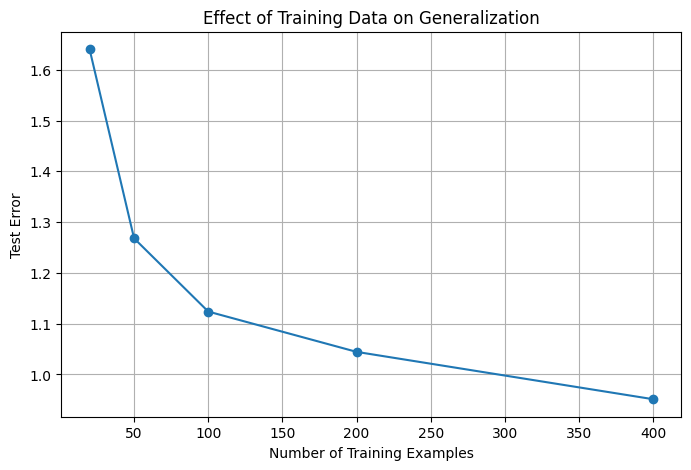

In [3]:
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = np.random.uniform(-3, 3, 500)
y = X**2 + np.random.normal(0, 1, 500)

sample_sizes = [20, 50, 100, 200, 400]

test_errors = []

for size in sample_sizes:

    X_train = X[:size]
    y_train = y[:size]

    X_test = X[size:]
    y_test = y[size:]

    model = make_pipeline(
        PolynomialFeatures(5),
        LinearRegression()
    )

    model.fit(X_train.reshape(-1, 1), y_train)

    predictions = model.predict(
        X_test.reshape(-1, 1)
    )

    error = mean_squared_error(
        y_test,
        predictions
    )

    test_errors.append(error)

plt.figure(figsize=(8, 5))

plt.plot(
    sample_sizes,
    test_errors,
    marker="o"
)

plt.xlabel("Number of Training Examples")
plt.ylabel("Test Error")
plt.title("Effect of Training Data on Generalization")

plt.grid()

plt.show()

## Why More Data Helps

A model trained on a very small dataset has limited information about the underlying distribution.

With more training examples:

$$
n\uparrow
$$

the learning algorithm receives more information about the data-generating process.

This usually reduces uncertainty and improves generalization.

Conceptually:

$$
\text{More representative data}
\Rightarrow
\text{Better estimate of the underlying pattern}
$$

However, more data does not automatically solve every problem.

Data quality, distribution shift, label noise, and model assumptions still matter.

# 26. Overfitting from the Statistical Learning Theory Perspective

Overfitting occurs when a model fits the training data extremely well but fails to generalize.

From the SLT perspective, this can happen when:

$$
\text{Model capacity}
\gg
\text{Available information in the data}
$$

The model has enough flexibility to represent accidental patterns or noise.

This leads to:

$$
\hat{R}(h)\downarrow
$$

while:

$$
R(h)\uparrow
$$

Therefore:

$$
\text{Training performance improves}
$$

but:

$$
\text{Generalization performance deteriorates}
$$

This is why controlling model complexity is fundamental to learning theory.

# 27. Regularization vs More Data

There are two common ways to improve generalization.

### 1. Increase the amount of data

$$
n\uparrow
$$

More data gives the model more information.

### 2. Control model complexity

For example:

- Regularization
- Smaller models
- Pruning
- Early stopping
- Feature selection

Conceptually:

$$
\text{Generalization}
\uparrow
\quad\text{when}\quad
\begin{cases}
\text{Data increases}\\
\text{Complexity is controlled}
\end{cases}
$$

In practical machine learning, both strategies are often used together.

# 28. No Free Lunch Theorem

The **No Free Lunch Theorem** provides an important perspective on machine learning.

Informally:

> No single learning algorithm is guaranteed to perform best on every possible problem.

An algorithm that performs extremely well on one type of problem may perform poorly on another.

For example:

- Linear models work well when relationships are approximately linear.
- Tree-based models can capture nonlinear interactions.
- Neural networks are powerful for highly complex patterns.
- Kernel methods can capture certain nonlinear structures.

Therefore, successful machine learning requires assumptions about the problem and the data.

These assumptions are sometimes called **inductive biases**.

# 29. Inductive Bias

An **inductive bias** is the set of assumptions that a learning algorithm uses to generalize beyond the observed training data.

Examples:

### Linear Regression

Assumes the relationship can be approximated by a linear function.

### Decision Trees

Prefer hierarchical feature-based decision rules.

### K-Nearest Neighbors

Assumes nearby examples tend to have similar targets.

### Neural Networks

Use architectural assumptions and optimization procedures that influence the functions they learn.

Inductive bias is necessary because finite training data cannot uniquely determine the correct function in general.

Therefore:

$$
\text{Learning}
=
\text{Data}
+
\text{Inductive Bias}
$$

# 30. Practical Model Selection

Statistical Learning Theory gives us a useful way to think about model selection.

We want to balance:

$$
\text{Training Fit}
$$

and:

$$
\text{Model Complexity}
$$

A useful conceptual objective is:

$$
\text{Good Model}
=
\text{Low Error}
+
\text{Controlled Complexity}
$$

In practice, we use techniques such as:

- Train/validation/test split
- Cross-validation
- Regularization
- Hyperparameter tuning
- Early stopping
- Feature selection
- Model comparison

These methods help estimate how well a model is likely to generalize.

# 31. Statistical Learning Theory and Cross-Validation

Cross-validation is a practical method for estimating generalization performance.

The dataset is divided into multiple folds.

For each fold:

1. Train on the remaining folds
2. Validate on the selected fold
3. Record the validation performance

The final estimate is usually:

$$
CV\ Score
=
\frac{1}{k}
\sum_{i=1}^{k}
Score_i
$$

Cross-validation does not directly calculate the theoretical true risk.

Instead, it provides a practical estimate of how the model may perform on unseen data.

This connects the practical workflow of model selection with the theoretical goal of minimizing generalization error.

# 32. Complete Conceptual Picture

The learning process can be viewed as:

$$
\text{Unknown Distribution}
\rightarrow
\text{Training Data}
\rightarrow
\text{Learning Algorithm}
\rightarrow
\text{Hypothesis}
\rightarrow
\text{Predictions}
$$

The central challenge is:

$$
\boxed{
\text{Training Performance}
\neq
\text{Guaranteed Generalization}
}
$$

Statistical Learning Theory explains this gap using concepts such as:

- Empirical risk
- True risk
- Generalization
- Hypothesis complexity
- VC dimension
- PAC learning
- Sample complexity
- Regularization
- Structural Risk Minimization

# 33. Important Relationships

### More Data

$$
n\uparrow
\Rightarrow
\text{Generalization usually improves}
$$

### Higher Complexity

$$
\text{Complexity}\uparrow
\Rightarrow
\text{Capacity}\uparrow
$$

but potentially:

$$
\text{Overfitting risk}\uparrow
$$

### Regularization

$$
\lambda\uparrow
\Rightarrow
\text{Effective complexity}\downarrow
$$

### Training Error

$$
\hat{R}(h)
$$

measures performance on observed data.

### True Risk

$$
R(h)
$$

measures expected performance on the underlying distribution.

### Generalization Gap

$$
R(h)-\hat{R}(h)
$$

measures the difference between true and empirical risk.

# 34. Statistical Learning Theory vs Practical Machine Learning

Statistical Learning Theory provides theoretical tools for understanding learning.

Practical machine learning uses algorithms and techniques to build models.

| Statistical Learning Theory | Practical Machine Learning |
|---|---|
| True Risk | Test Error |
| Empirical Risk | Training Error |
| Generalization | Test Performance |
| Hypothesis Space | Model Family |
| VC Dimension | Model Capacity |
| Sample Complexity | Required Dataset Size |
| SRM | Model Selection |
| Complexity Control | Regularization |
| PAC Guarantees | Validation and Testing |

Theory helps explain why many practical machine learning techniques work.

## 35. Mini Experiment — Underfitting, Good Fit, Overfitting

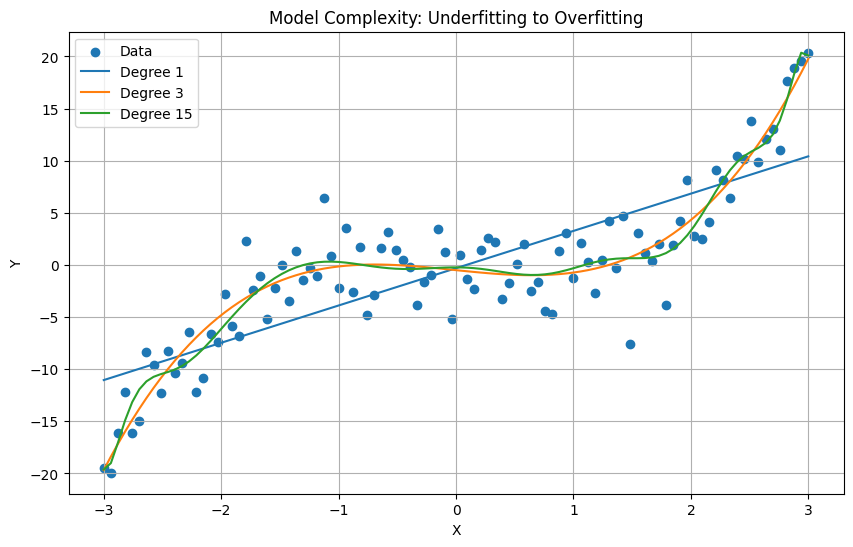

In [4]:
np.random.seed(42)

X = np.linspace(-3, 3, 100)

y = X**3 - 2 * X + np.random.normal(0, 3, 100)

degrees = [1, 3, 15]

plt.figure(figsize=(10, 6))

plt.scatter(X, y, label="Data")

for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X.reshape(-1, 1), y)

    predictions = model.predict(
        X.reshape(-1, 1)
    )

    plt.plot(
        X,
        predictions,
        label=f"Degree {degree}"
    )

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Model Complexity: Underfitting to Overfitting")

plt.legend()
plt.grid()

plt.show()

## Interpreting the Experiment

### Degree 1

The model is too simple to capture the nonlinear relationship.

This is an example of **underfitting**.

Characteristics:

$$
\text{High Bias}
$$

### Degree 3

The model has enough flexibility to capture the underlying relationship.

This often provides a good balance.

Characteristics:

$$
\text{Good Generalization}
$$

### Degree 15

The model is highly flexible and can begin fitting noise.

This is an example of **overfitting**.

Characteristics:

$$
\text{High Variance}
$$

The experiment demonstrates the practical connection between:

$$
\boxed{
\text{Model Complexity}
\rightarrow
\text{Generalization}
}
$$

# 37. Key Takeaways

1. Statistical Learning Theory studies the mathematical foundations of machine learning.

2. A hypothesis is a possible model, while the hypothesis space contains all candidate models.

3. Empirical risk measures average loss on training data:

$$
\hat{R}(h)
=
\frac{1}{n}
\sum_{i=1}^{n}
L(y_i,h(x_i))
$$

4. True risk measures expected loss on the underlying data distribution:

$$
R(h)
=
\mathbb{E}[L(Y,h(X))]
$$

5. Generalization means performing well on unseen data.

6. A model can have low training error but high true error.

7. PAC learning describes learning with approximately correct performance and high probability.

8. VC dimension measures the expressive capacity of a hypothesis class.

9. More complex models generally require more data to generalize reliably.

10. Regularization controls model complexity.

11. Structural Risk Minimization balances empirical error and model complexity.

12. Cross-validation provides a practical estimate of generalization performance.

13. There is no universally best learning algorithm.

14. Machine learning is fundamentally a problem of learning useful patterns from finite data while controlling generalization error.

# 38. Final Mental Model

The most important idea in Statistical Learning Theory is:

$$
\boxed{
\text{Good Machine Learning}
=
\text{Fit the Data}
+
\text{Generalize Beyond the Data}
}
$$

Training data tells us what happened in the observed sample.

Statistical Learning Theory asks whether what we learned from that sample will continue to work on unseen samples.

The central tradeoff is:

$$
\boxed{
\text{Model Complexity}
\leftrightarrow
\text{Generalization}
}
$$

Too little complexity:

$$
\rightarrow
\text{Underfitting}
$$

Too much complexity:

$$
\rightarrow
\text{Overfitting}
$$

Appropriate complexity:

$$
\rightarrow
\text{Good Generalization}
$$

This is the theoretical foundation behind many practical machine learning techniques studied throughout this course.